# Predictive Modelling of Proteomics using a Transformer Model

## Task Type and Model Decision
This task is a regression task, where one type of omics data is predicted using others. Both VAEs and Transformers are suitable choices: VAEs excel with noisy data and handle missing values well, while Transformers are powerful for capturing complex interactions between features through their self-attention mechanism.

I selected a Transformer model because the multi-head attention can learn different types of relationships between omics data features and capturing various correlations that might exist. The self-attention mechanism allows the model to identify important feature interactions, which I think are important in multi-omics data integration. While VAEs would also be suitable, particularly for handling noise and missing values, the potential complex interactions between omics data features made Transformers my preferred choice.

## Data
The aim is to use multiple input omics datasets to predict proteomics data. Input omics data was selected by iteratively testing combinations to determine which best predicted proteomics. This indicated that transcriptomics data only as the optimal input combination for proteomics prediction.

## Plan
The approach follows a systematic comparison between a baseline MLP model and the Transformer architecture:

#### In EMBL_transformer_explore.ipynb
1. [Inspect data](#inspect-data);
2. [Create a simple MLP model](#baseline-mlp) as a baseline;
3. [Develop Transformer models](#transformer-models) with different fusion strategies and activation functions;
4. [Perform hyperparameter tuning](#hyperparameter-tuning);
5. [Conduct progressive input omics selection](#omics-selection);
6. [Create comprehensive loop](#evaluation-loop) to iterate through steps 3-5, obtaining metrics to determine the best Transformer model for comparison with the baseline MLP;

#### In EMBL_transformer_best_model.ipynb
7. [Select best-performing model](#best-performing);
8. [Analyse best-predicted proteomic features](#feature-analysis);


## Results
- The [baseline MLP model](#results-MLP) performed quite well already, with an R^2 ~0.83, an RMSE ~0.69, and prediction errors that are roughly Normally distributed.
- The best [Transformer model](#results-transformer) demonstrated that using transcriptomics data only as input omics data performed best, with R^2 ~0.83. However, rerunning the algorithm shows some variability in the best performing hyperparameters, such as fusion method selected. In addition, the Transformer model does not significantly outperform the baseline MLP model. Moving forward, cross-validation and improved data handling (e.g. outlier handling) would be worth exploring. 
- The results of the [feature analysis](#results-feature-analysis) showed significant correlation values >0.5 between the predicted and actual values. However, the R^2 values are low, indicating that while the general trends in protein expression are captured, the model does not accurately predict the exact values. 

## Future Work
Given more time, I would implement:

1. Cross-validation for more robust model evaluation;
2. Enhanced data handling, particularly for outliers. Despite the task stating the data was "processed and cleaned, so you can use them directly" I encountered outliers that might affect results. Going forward, I would address these outliers prior to modelling;
3. Development of ensemble methods to potentially improve prediction accuracy.



In [1]:
from IPython.display import display, HTML
import numpy as np
import pandas as pd
import math
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.gridspec as gridspec

from scipy.stats import zscore, pearsonr

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import optuna

In [2]:
# for using VSCode
import sys
from pathlib import Path

# Add the parent directory of transformer_multiomics to sys.path
sys.path.append(str(Path.cwd().parent))

In [3]:
from transformer_multiomics.config import MODEL_PATH, RESULT_PATH, DATA_PATH
from transformer_multiomics.data.data_loader import ensure_directories_exist, load_datasets
from transformer_multiomics.data.data_preparation import get_multiomics_dataloaders, prepare_data_loaders
from transformer_multiomics.models.mlp import MultiOmicsMLP
from transformer_multiomics.models.transformer import ModularMultiOmicsTransformer
from transformer_multiomics.training.trainer import train_model
from transformer_multiomics.utils.plots import plot_loss_curves, plot_error_distribution
from transformer_multiomics.training.evaluater import evaluate_model, summarise_results, analyse_feature_level_performance
from transformer_multiomics.training.optimizing import progressive_omics_selection

In [4]:
# CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
# Ensure directories exist
ensure_directories_exist(MODEL_PATH, RESULT_PATH, DATA_PATH)

# Load datasets
datasets = load_datasets()
print("Available datasets:", datasets.keys())

Directory exists: /home/jantine/Projects/transformer_multiomics/models
Directory exists: /home/jantine/Projects/transformer_multiomics/results
Directory exists: /home/jantine/Projects/transformer_multiomics/datasets
Available datasets: dict_keys(['methylation', 'metabolomics', 'proteomics', 'transcriptomics', 'cnv'])


# MLP Base Model <a id="baseline-mlp"></a> 
The idea is to start with a simple MLP base model with a few hidden layers to serve as a benchmark for the Transformer. This base model will also only use one type of input omics data, i.e. transcriptomics, to predict the proteomics data.  

In [6]:
# Choose input data set and target
input_datasets = ["transcriptomics", "methylation", "metabolomics", "cnv"]  # as many as you want
target_dataset = "proteomics"

train_loader, test_loader = get_multiomics_dataloaders(
    datasets=datasets,
    input_omics=input_datasets,
    target_omics=target_dataset,
    batch_size=32,
    test_size=0.2
)

# Define input dims per omics
input_dims_dict = {
    omic: datasets[omic].shape[1] - 1  # exclude patient ID column
    for omic in input_datasets
}

# Output dimension (target omic)
output_dim = datasets[target_dataset].shape[1] - 1

In [7]:
# Initialize model with multi-omics input dims
mlp_model = MultiOmicsMLP(
    input_dims_dict=input_dims_dict,
    output_dim=output_dim,
    hidden_dims=[256, 128, 64]
).to(device)

# Loss function and optimiser
mlp_criterion = nn.MSELoss()
learning_rate = 0.001
weight_decay = 0
mlp_optimiser = optim.Adam(mlp_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Early stopping setup
patience = 15
epochs = 100

mlp_model = MultiOmicsMLP(
    input_dims_dict=input_dims_dict,
    output_dim=output_dim,
    hidden_dims=[256, 128, 64]
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=0)

trained_model, train_losses, test_losses, best_loss = train_model(
    model=mlp_model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=epochs,
    patience=patience,
    model_name="multiomics_mlp",
    save_path=MODEL_PATH,
    return_attention_weights=False
)



Starting training for multiomics_mlp...


Epoch 1/100 | Train Loss: 27.2228 | Test Loss: 17.2635 | Early Stopping: 0/15


Epoch 11/100 | Train Loss: 0.9761 | Test Loss: 0.8542 | Early Stopping: 0/15


Epoch 21/100 | Train Loss: 0.4401 | Test Loss: 0.4896 | Early Stopping: 0/15


Epoch 31/100 | Train Loss: 0.4504 | Test Loss: 0.4708 | Early Stopping: 0/15


...

Epoch 61/100 | Train Loss: 0.3258 | Test Loss: 0.3467 | Early Stopping: 1/15


Epoch 71/100 | Train Loss: 0.3217 | Test Loss: 0.3347 | Early Stopping: 0/15


Epoch 81/100 | Train Loss: 0.3175 | Test Loss: 0.3540 | Early Stopping: 2/15


Epoch 91/100 | Train Loss: 0.3175 | Test Loss: 0.3268 | Early Stopping: 0/15


Epoch 100/100 | Train Loss: 0.3122 | Test Loss: 0.3253 | Early Stopping: 3/15
Best model saved to /home/jantine/Projects/transformer_multiomics/models/best_multiomics_mlp_model.pt


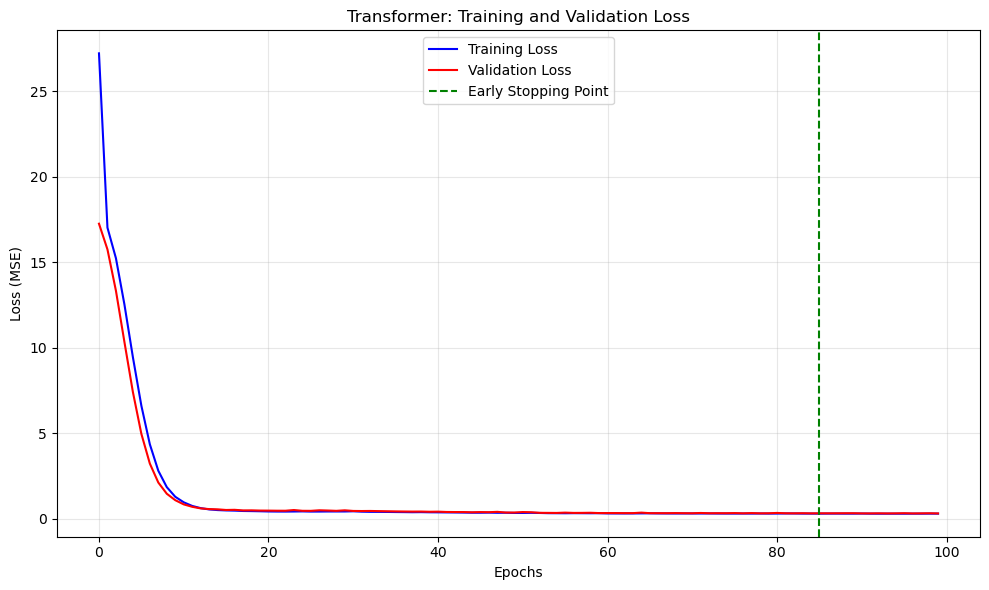

In [8]:
# Plot training and validation loss curves
early_stopping_epoch = len(test_losses) - patience
plot_loss_curves(
    train_losses,
    test_losses,
    early_stopping_epoch=early_stopping_epoch,
    title="Transformer: Training and Validation Loss"
)

In [9]:
# Evaluate model performance
metrics_mlp = evaluate_model(mlp_model, test_loader, device, is_transformer=False, model_name="MLP")


Evaluating MLP: 100%|██████████| 2/2 [00:00<00:00, 268.44it/s]

MLP Performance:
R-squared (R²): 0.8907
Root Mean Squared Error (RMSE): 0.5704
Mean Absolute Error (MAE): 0.4182
Explained Variance Score: 0.8908


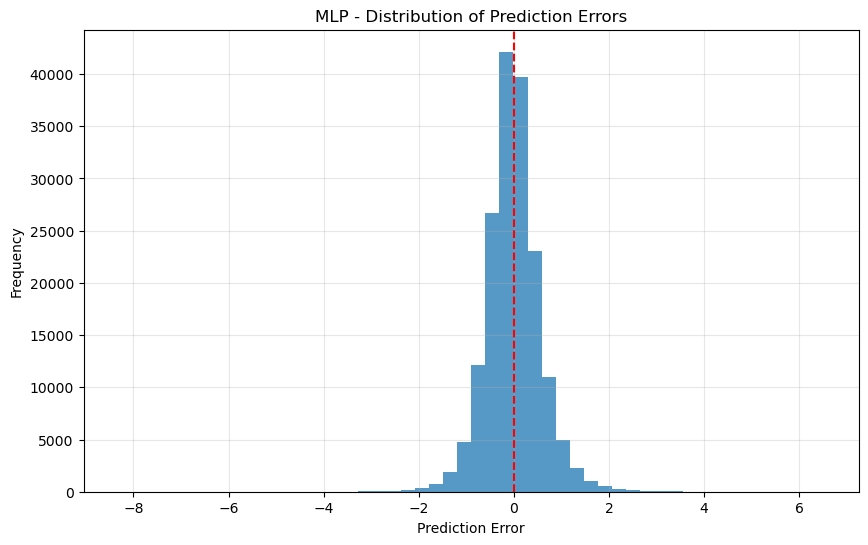

In [10]:
# Plot error distribution
all_predictions = metrics_mlp["predictions"]
all_targets = metrics_mlp["targets"]

plot_error_distribution(all_predictions, all_targets, model_name="MLP")


# Baseline MLP Results <a id="results-MLP"></a>

The MLP is performing quite well already, with R^2 of ~0.83 and the error distribution normally distributed. The errors look Normally distributed, so the MLP is already performing well without systematically overestimating/underestimating the target values. 

# Transformer <a id="transformer-models"></a> 

This part is the development of the Transformer model. The Transformer model is designed so that it can be used to iteratively scan through different combinations of input omics data, fusion strategies, activation function (only ReLU and GeLU, as I'm working with PyTorch), and for hyperparameter optimisation.

## Hyperparameter Tuning <a id="hyperparameter-tuning"></a> 

[I 2025-06-28 16:43:41,521] A new study created in memory with name: no-name-4b24d71d-b7e8-4131-b677-317f2aed72db



Optimising hyperparameters for omics set: ['transcriptomics']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-06-28 16:43:44,314] Trial 0 finished with value: 5.633918285369873 and parameters: {'num_heads': 8, 'num_layers': 3, 'hidden_dim': 320, 'dropout_rate': 0.2, 'learning_rate': 0.0001359467388883183, 'weight_decay': 9.759154313939676e-06, 'fusion_method': 'late', 'activation_function': 'relu'}. Best is trial 0 with value: 5.633918285369873.
[I 2025-06-28 16:43:46,529] Trial 1 finished with value: 0.4525826871395111 and parameters: {'num_heads': 4, 'num_layers': 5, 'hidden_dim': 320, 'dropout_rate': 0.0, 'learning_rate': 0.0005064469038137229, 'weight_decay': 0.000156175494774077, 'fusion_method': 'weighted', 'activation_function': 'relu'}. Best is trial 1 with value: 0.4525826871395111.
[I 2025-06-28 16:43:50,865] Trial 2 finish


Best hyperparameters:
  num_heads: 8
  num_layers: 2
  hidden_dim: 512
  dropout_rate: 0.4
  learning_rate: 0.0008752910951995919
  weight_decay: 1.2223790999926786e-06
  fusion_method: late
  activation_function: gelu

Best validation loss: 0.379866

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics']
--------------------------------------------------------------------------------
Epoch 0/200, Train Loss: 16.2482, Val Loss: 13.2485
Learning rate: 0.000875
Epoch 10/200, Train Loss: 0.5908, Val Loss: 0.4452
Learning rate: 0.000869
Epoch 20/200, Train Loss: 0.4971, Val Loss: 0.3845
Learning rate: 0.000852
Epoch 30/200, Train Loss: 0.4929, Val Loss: 0.3804
Learning rate: 0.000824
Epoch 40/200, Train Loss: 0.4945, Val Loss: 0.3809
Learning rate: 0.000788
Epoch 50/200, Train Loss: 0.4931, Val Loss: 0.3808
Learning rate: 0.000742
Early stopping at epoch 54

Performance for omics set ['transcriptomics']:
R-s

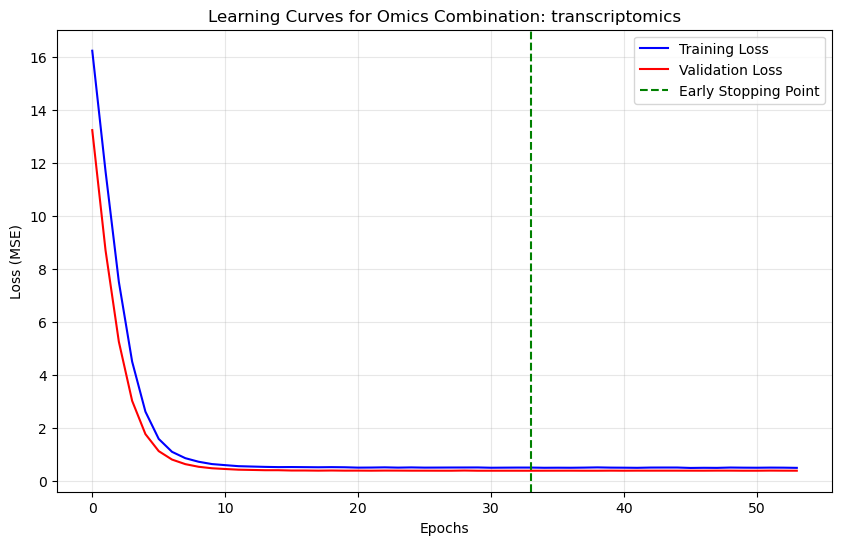


Baseline with ['transcriptomics']: R² = 0.8356


,Step,Current Set,R²,RMSE
0,0,transcriptomics,0.835617,0.699475


[I 2025-06-28 16:44:40,718] A new study created in memory with name: no-name-670c5055-a9d6-4b46-8da6-8976d1109314



Testing omics set: ['transcriptomics', 'methylation']

Optimising hyperparameters for omics set: ['transcriptomics', 'methylation']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-06-28 16:44:44,937] Trial 0 finished with value: 8.620721817016602 and parameters: {'num_heads': 4, 'num_layers': 3, 'hidden_dim': 320, 'dropout_rate': 0.0, 'learning_rate': 8.196098882677671e-05, 'weight_decay': 5.783943653393562e-06, 'fusion_method': 'cross_attention', 'activation_function': 'gelu'}. Best is trial 0 with value: 8.620721817016602.
[I 2025-06-28 16:44:49,611] Trial 1 finished with value: 0.7492225170135498 and parameters: {'num_heads': 4, 'num_layers': 2, 'hidden_dim': 384, 'dropout_rate': 0.1, 'learning_rate': 0.00028232000537460193, 'weight_decay': 1.442636361879167e-06, 'fusion_method': 'gated', 'activation_function': 'gelu'}. Best is trial 1 with value: 0.7492225170135498.
[I 2025-06-28 16:44:54,098] Tria


Best hyperparameters:
  num_heads: 16
  num_layers: 6
  hidden_dim: 448
  dropout_rate: 0.4
  learning_rate: 0.0009330843482308342
  weight_decay: 0.0001230559124376118
  fusion_method: cross_attention
  activation_function: gelu

Best validation loss: 0.380252

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'methylation']
--------------------------------------------------------------------------------
Epoch 0/200, Train Loss: 16.2417, Val Loss: 13.2883
Learning rate: 0.000933
Epoch 10/200, Train Loss: 0.5973, Val Loss: 0.4566
Learning rate: 0.000926
Epoch 20/200, Train Loss: 0.5039, Val Loss: 0.3825
Learning rate: 0.000908
Epoch 30/200, Train Loss: 0.4906, Val Loss: 0.3824
Learning rate: 0.000879
Epoch 40/200, Train Loss: 0.4982, Val Loss: 0.3819
Learning rate: 0.000840
Epoch 50/200, Train Loss: 0.4888, Val Loss: 0.3829
Learning rate: 0.000791
Epoch 60/200, Train Loss: 0.4941, Val Loss: 0.3815
L

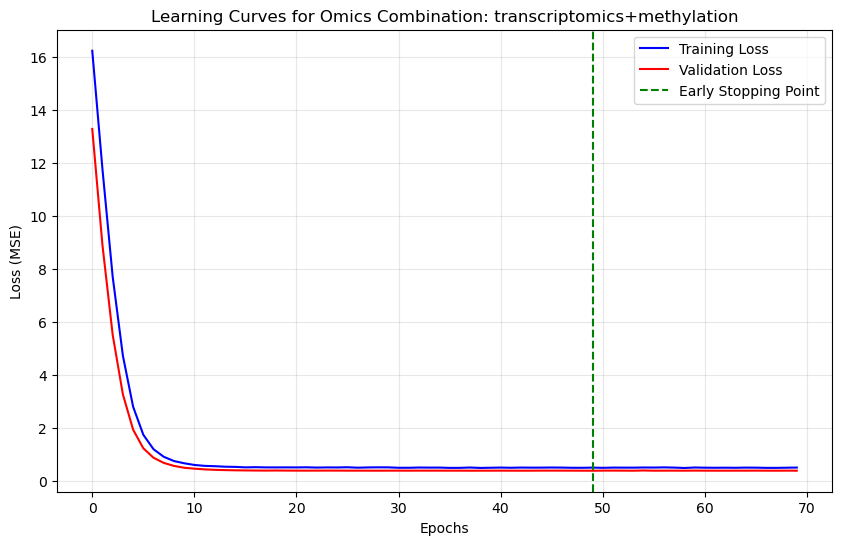

[I 2025-06-28 16:46:15,855] A new study created in memory with name: no-name-e4f5c62c-8161-41cd-b619-8d8973ba6cf0


Adding methylation → R² = 0.8368 (Δ = +0.0011)

Testing omics set: ['transcriptomics', 'metabolomics']

Optimising hyperparameters for omics set: ['transcriptomics', 'metabolomics']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-06-28 16:46:19,426] Trial 0 finished with value: 2.4281466007232666 and parameters: {'num_heads': 4, 'num_layers': 2, 'hidden_dim': 448, 'dropout_rate': 0.0, 'learning_rate': 0.00015930131827939255, 'weight_decay': 1.0776636811286962e-05, 'fusion_method': 'gated', 'activation_function': 'relu'}. Best is trial 0 with value: 2.4281466007232666.
[I 2025-06-28 16:46:23,363] Trial 1 finished with value: 17.104158401489258 and parameters: {'num_heads': 4, 'num_layers': 2, 'hidden_dim': 128, 'dropout_rate': 0.1, 'learning_rate': 1.5186619742980388e-05, 'weight_decay': 8.743604438970714e-05, 'fusion_method': 'weighted', 'activation_function': 'relu'}. Best is trial 0 with value: 2.4281466007232666.
[I 2025-06-28 16:46:26,664] Trial 2


Best hyperparameters:
  num_heads: 8
  num_layers: 5
  hidden_dim: 512
  dropout_rate: 0.30000000000000004
  learning_rate: 0.0005826033978377753
  weight_decay: 1.0813885353580874e-05
  fusion_method: cross_attention
  activation_function: relu

Best validation loss: 0.381054

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'metabolomics']
--------------------------------------------------------------------------------
Epoch 0/200, Train Loss: 16.2928, Val Loss: 13.8622
Learning rate: 0.000583
Epoch 10/200, Train Loss: 0.7788, Val Loss: 0.6030
Learning rate: 0.000578
Epoch 20/200, Train Loss: 0.5005, Val Loss: 0.3838
Learning rate: 0.000567
Epoch 30/200, Train Loss: 0.4928, Val Loss: 0.3809
Learning rate: 0.000549
Epoch 40/200, Train Loss: 0.4932, Val Loss: 0.3818
Learning rate: 0.000524
Early stopping at epoch 47

Performance for omics set ['transcriptomics', 'metabolomics']:
R-squared (R²): 0.8

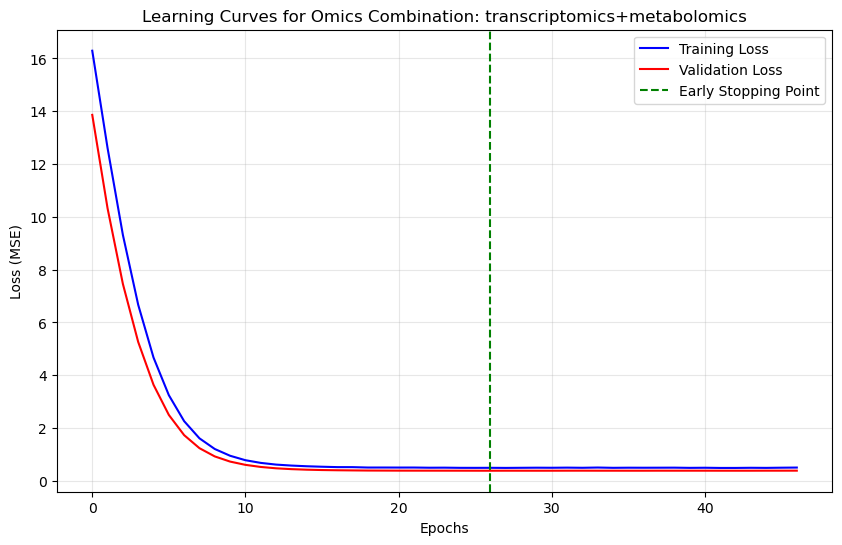

[I 2025-06-28 16:47:36,166] A new study created in memory with name: no-name-25b1b74b-8603-4a4f-8f4a-c05adf0227c7


Adding metabolomics → R² = 0.8375 (Δ = +0.0019)

Testing omics set: ['transcriptomics', 'cnv']

Optimising hyperparameters for omics set: ['transcriptomics', 'cnv']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-06-28 16:47:39,877] Trial 0 finished with value: 4.945286273956299 and parameters: {'num_heads': 4, 'num_layers': 3, 'hidden_dim': 256, 'dropout_rate': 0.4, 'learning_rate': 0.00018533736343450877, 'weight_decay': 0.0005591878176995408, 'fusion_method': 'gated', 'activation_function': 'relu'}. Best is trial 0 with value: 4.945286273956299.
[I 2025-06-28 16:47:43,153] Trial 1 finished with value: 11.221816062927246 and parameters: {'num_heads': 4, 'num_layers': 4, 'hidden_dim': 384, 'dropout_rate': 0.0, 'learning_rate': 4.381295694582996e-05, 'weight_decay': 6.218248426904516e-06, 'fusion_method': 'late', 'activation_function': 'gelu'}. Best is trial 0 with value: 4.945286273956299.
[I 2025-06-28 16:47:48,046] Trial 2 finished


Best hyperparameters:
  num_heads: 16
  num_layers: 2
  hidden_dim: 384
  dropout_rate: 0.2
  learning_rate: 0.0009523924390805446
  weight_decay: 1.1141859698225697e-06
  fusion_method: hierarchical
  activation_function: gelu

Best validation loss: 0.380314

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'cnv']
--------------------------------------------------------------------------------
Epoch 0/200, Train Loss: 16.2625, Val Loss: 13.4237
Learning rate: 0.000952
Epoch 10/200, Train Loss: 0.6032, Val Loss: 0.4705
Learning rate: 0.000945
Epoch 20/200, Train Loss: 0.4755, Val Loss: 0.3828
Learning rate: 0.000927
Epoch 30/200, Train Loss: 0.4809, Val Loss: 0.3803
Learning rate: 0.000897
Epoch 40/200, Train Loss: 0.4678, Val Loss: 0.3869
Learning rate: 0.000857
Epoch 50/200, Train Loss: 0.4478, Val Loss: 0.3811
Learning rate: 0.000808
Early stopping at epoch 58

Performance for omics set ['transc

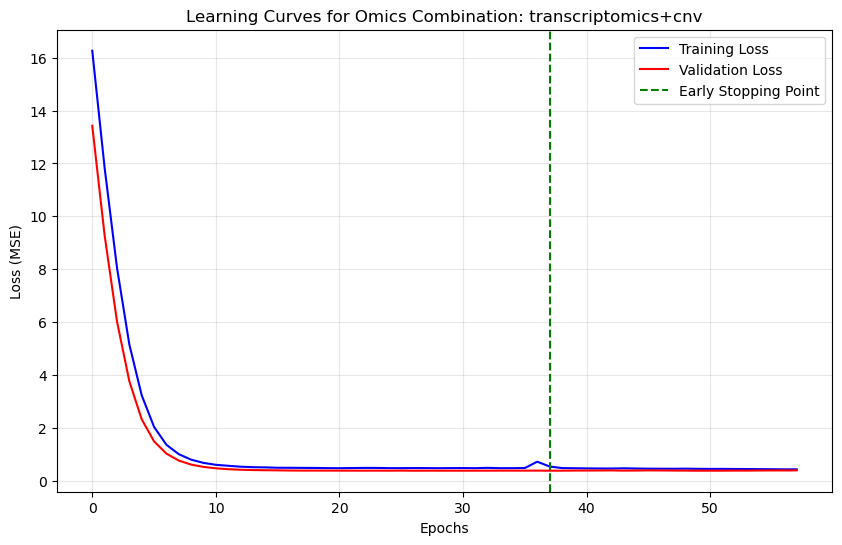

Adding cnv → R² = 0.8285 (Δ = -0.0071)


,Added Omics,Test Set,R²,RMSE,Improvement
1,metabolomics,transcriptomics+metabolomics,0.837546,0.695359,0.001929
0,methylation,transcriptomics+methylation,0.836762,0.697035,0.001145
2,cnv,transcriptomics+cnv,0.828544,0.714365,-0.007073



Added metabolomics. New best set: ['transcriptomics', 'metabolomics'], R²: 0.8375


,Step,Current Set,R²,RMSE,Added
0,0,transcriptomics,0.835617,0.699475,NaN
0,1,transcriptomics+metabolomics,0.837546,0.695359,metabolomics


[I 2025-06-28 16:48:55,336] A new study created in memory with name: no-name-f878a598-2ac4-499f-911d-cc67c633472c



Testing omics set: ['transcriptomics', 'metabolomics', 'methylation']

Optimising hyperparameters for omics set: ['transcriptomics', 'metabolomics', 'methylation']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-06-28 16:49:00,409] Trial 0 finished with value: 0.4816913902759552 and parameters: {'num_heads': 8, 'num_layers': 3, 'hidden_dim': 192, 'dropout_rate': 0.4, 'learning_rate': 0.0007340900782232295, 'weight_decay': 4.309917250590194e-06, 'fusion_method': 'late', 'activation_function': 'relu'}. Best is trial 0 with value: 0.4816913902759552.
[I 2025-06-28 16:49:06,147] Trial 1 finished with value: 0.5635127425193787 and parameters: {'num_heads': 16, 'num_layers': 5, 'hidden_dim': 512, 'dropout_rate': 0.4, 'learning_rate': 0.0002572146241495694, 'weight_decay': 4.801825832448055e-06, 'fusion_method': 'late', 'activation_function': 'relu'}. Best is trial 0 with value: 0.4816913902759552.
[I 2025-06-28 16:49:12,904] Trial 2 finish


Best hyperparameters:
  num_heads: 4
  num_layers: 2
  hidden_dim: 320
  dropout_rate: 0.1
  learning_rate: 0.0009734378635323869
  weight_decay: 0.0001103306240650986
  fusion_method: weighted
  activation_function: gelu

Best validation loss: 0.380680

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'metabolomics', 'methylation']
--------------------------------------------------------------------------------
Epoch 0/200, Train Loss: 16.4891, Val Loss: 14.0802
Learning rate: 0.000973
Epoch 10/200, Train Loss: 0.6686, Val Loss: 0.5317
Learning rate: 0.000966
Epoch 20/200, Train Loss: 0.4668, Val Loss: 0.3832
Learning rate: 0.000947
Epoch 30/200, Train Loss: 0.4709, Val Loss: 0.3839
Learning rate: 0.000917
Epoch 40/200, Train Loss: 0.4655, Val Loss: 0.3808
Learning rate: 0.000876
Epoch 50/200, Train Loss: 0.4741, Val Loss: 0.3815
Learning rate: 0.000826
Epoch 60/200, Train Loss: 0.4726, Val Loss: 

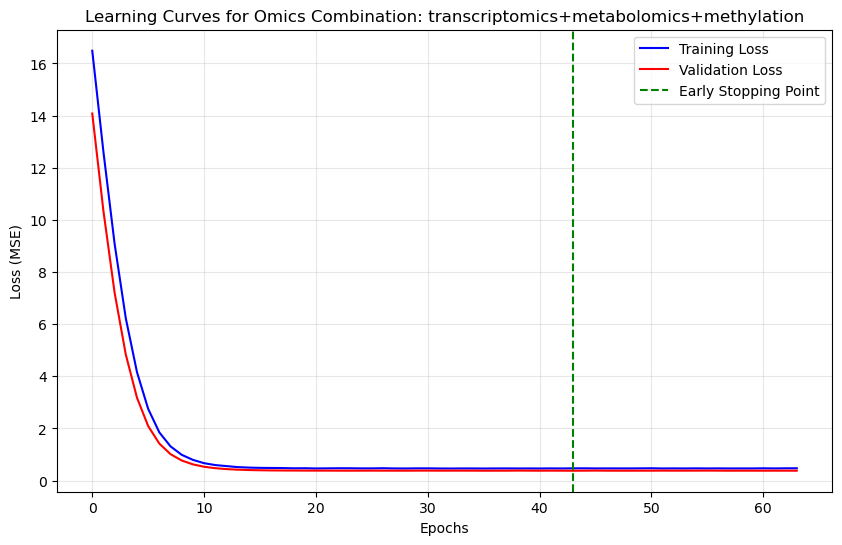

[I 2025-06-28 16:50:43,768] A new study created in memory with name: no-name-8ebaf03a-8534-4171-b3ee-d8d06197c3a2


Adding methylation → R² = 0.8372 (Δ = -0.0004)

Testing omics set: ['transcriptomics', 'metabolomics', 'cnv']

Optimising hyperparameters for omics set: ['transcriptomics', 'metabolomics', 'cnv']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-06-28 16:50:49,420] Trial 0 finished with value: 9.919843673706055 and parameters: {'num_heads': 8, 'num_layers': 6, 'hidden_dim': 512, 'dropout_rate': 0.5, 'learning_rate': 4.4603337096632976e-05, 'weight_decay': 6.508523180213224e-05, 'fusion_method': 'late', 'activation_function': 'relu'}. Best is trial 0 with value: 9.919843673706055.
[I 2025-06-28 16:50:53,753] Trial 1 finished with value: 0.3810746967792511 and parameters: {'num_heads': 16, 'num_layers': 2, 'hidden_dim': 384, 'dropout_rate': 0.2, 'learning_rate': 0.0008559732587830956, 'weight_decay': 1.315252347787705e-06, 'fusion_method': 'weighted', 'activation_function': 'relu'}. Best is trial 1 with value: 0.3810746967792511.
[I 2025-06-28 16:50:58,070] Trial 2 fin


Best hyperparameters:
  num_heads: 4
  num_layers: 4
  hidden_dim: 448
  dropout_rate: 0.4
  learning_rate: 0.0009182333770869516
  weight_decay: 9.189240838179496e-06
  fusion_method: gated
  activation_function: gelu

Best validation loss: 0.380152

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'metabolomics', 'cnv']
--------------------------------------------------------------------------------
Epoch 0/200, Train Loss: 16.2227, Val Loss: 13.4221
Learning rate: 0.000918
Epoch 10/200, Train Loss: 0.6132, Val Loss: 0.4574
Learning rate: 0.000911
Epoch 20/200, Train Loss: 0.5032, Val Loss: 0.3829
Learning rate: 0.000894
Epoch 30/200, Train Loss: 0.4937, Val Loss: 0.3828
Learning rate: 0.000865
Epoch 40/200, Train Loss: 0.4867, Val Loss: 0.3807
Learning rate: 0.000826
Epoch 50/200, Train Loss: 0.4826, Val Loss: 0.3827
Learning rate: 0.000779
Epoch 60/200, Train Loss: 0.4483, Val Loss: 0.4022
Lear

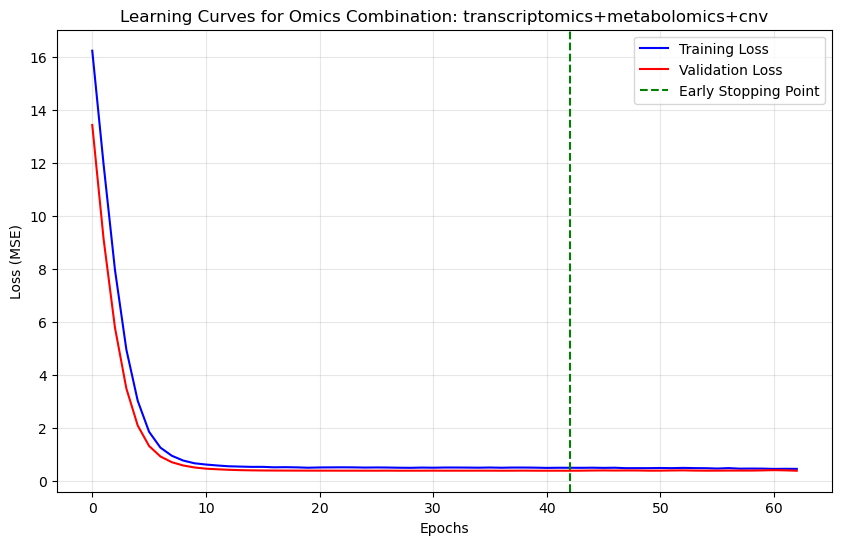

Adding cnv → R² = 0.8338 (Δ = -0.0037)


,Added Omics,Test Set,R²,RMSE,Improvement
0,methylation,transcriptomics+metabolomics+methylation,0.837165,0.696175,-0.000382
1,cnv,transcriptomics+metabolomics+cnv,0.833841,0.703243,-0.003705



No further improvement. Best set: ['transcriptomics', 'metabolomics'], R²: 0.8375


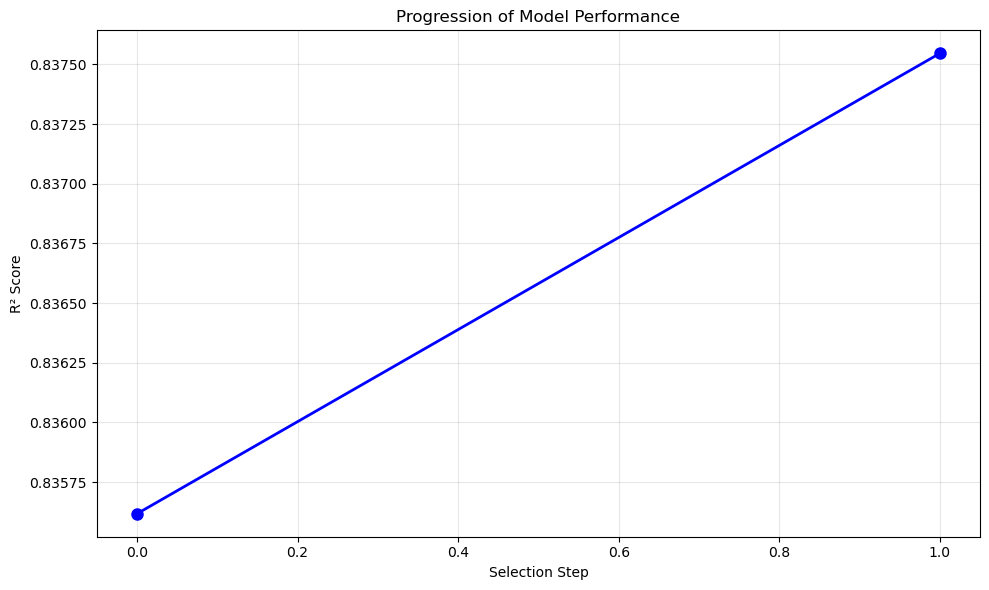



===== SUMMARY OF ALL COMBINATIONS =====
Omics Set                      R²         RMSE       MAE        EVS        Fusion          Activation
------------------------------------------------------------------------------------------
transcriptomics+metabolomics   0.8375     0.6954     0.5058     0.8380     cross_attention relu      
transcriptomics+metabolomics+methylation 0.8372     0.6962     0.5059     0.8378     weighted        gelu      
transcriptomics+methylation    0.8368     0.6970     0.5063     0.8377     cross_attention gelu      
transcriptomics                0.8356     0.6995     0.5072     0.8377     late            gelu      
transcriptomics+metabolomics+cnv 0.8338     0.7032     0.5107     0.8351     gated           gelu      
transcriptomics+cnv            0.8285     0.7144     0.5233     0.8297     hierarchical    gelu      


<Figure size 1200x800 with 0 Axes>

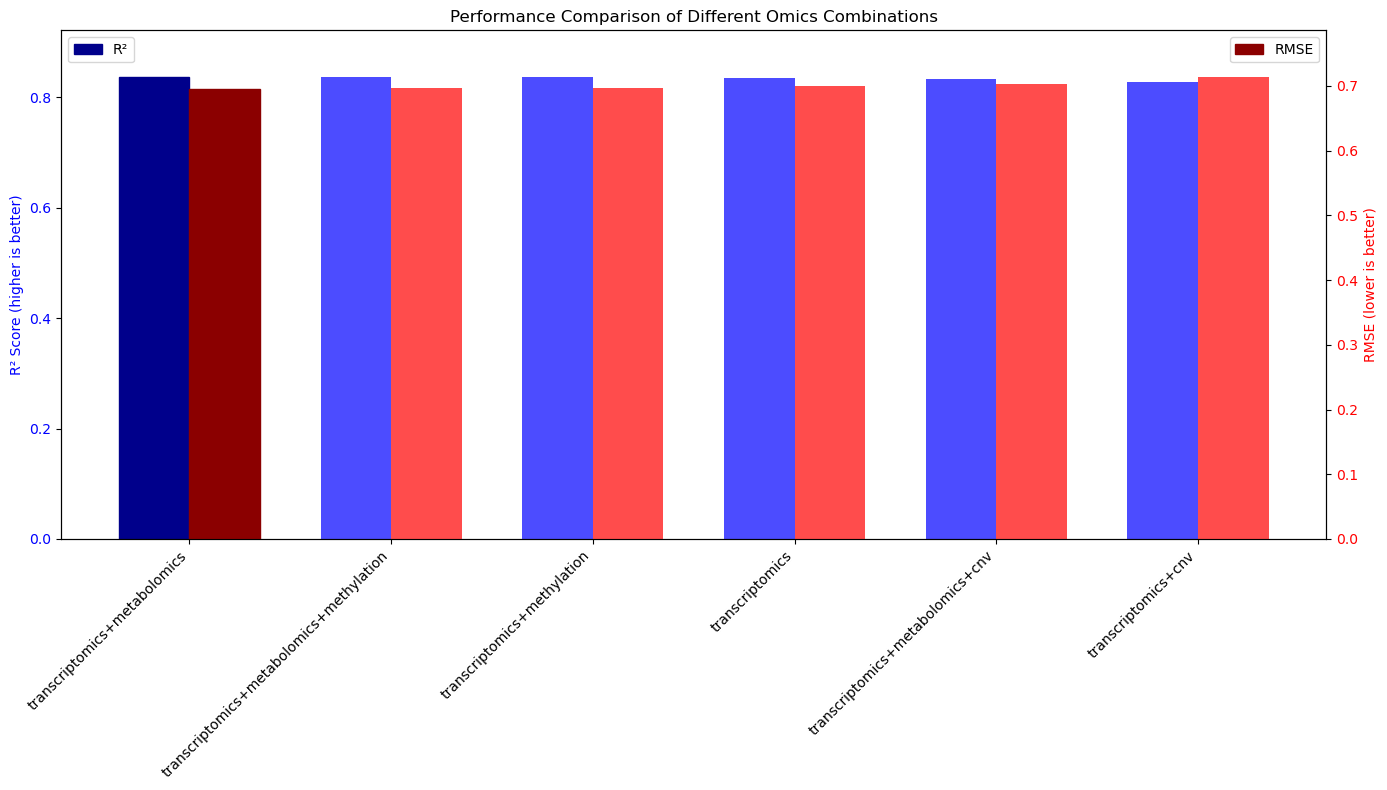

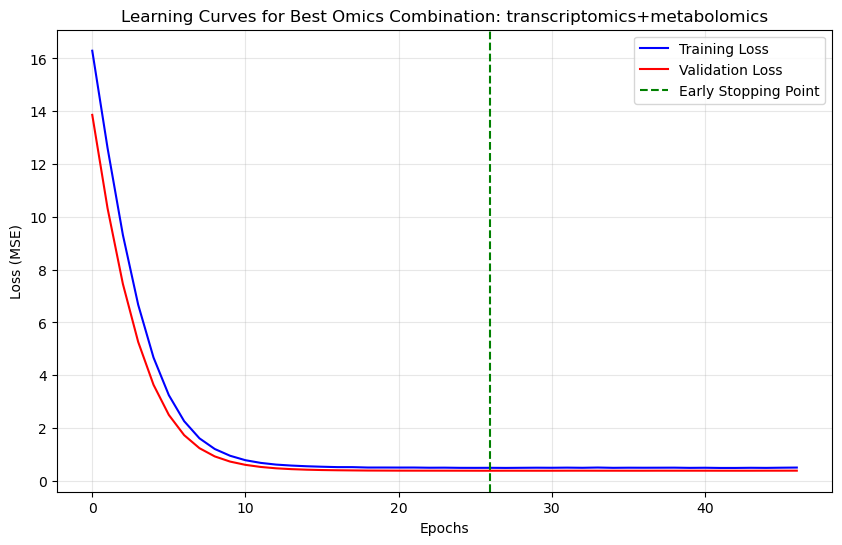

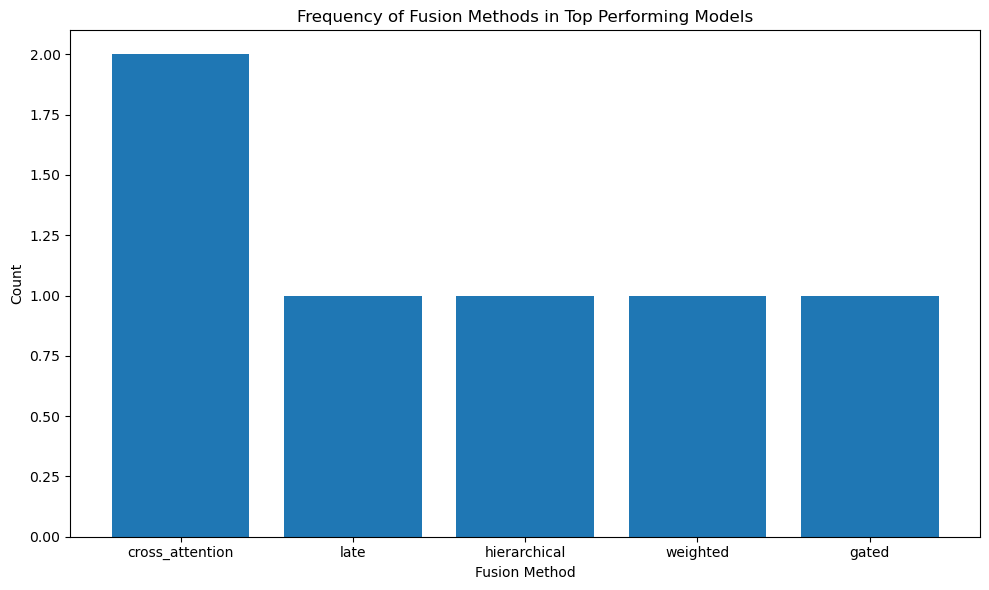


Best omics combination found: transcriptomics+metabolomics
Best R^2 score: 0.8375


(['transcriptomics', 'metabolomics'],
 {'num_heads': 8,
  'num_layers': 5,
  'hidden_dim': 512,
  'dropout_rate': 0.30000000000000004,
  'learning_rate': 0.0005826033978377753,
  'weight_decay': 1.0813885353580874e-05,
  'fusion_method': 'cross_attention',
  'activation_function': 'relu'})

In [17]:
# All omics list
all_omics_types = ["methylation", "metabolomics", "transcriptomics", "cnv"]

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Run the progressive selection process
all_results, best_omics_set, progress_df = progressive_omics_selection(all_omics_types, datasets, n_trials=20, device=device)

# Summarise the results
summary = summarise_results(all_results, best_omics_set)

# Save the progress dataframe
progress_df.to_csv(RESULT_PATH / "progressive_selection_results.csv", index=False)

# Print the best combination
print(f"\nBest omics combination found: {'+'.join(best_omics_set)}")
print(f"Best R^2 score: {all_results[tuple(best_omics_set)]['R2']:.4f}")

# Save the best model's hyperparameters
best_params = all_results[tuple(best_omics_set)]["Hyperparameters"]
best_params_df = pd.DataFrame([best_params])
best_params_df.to_csv(RESULT_PATH / "best_model_hyperparameters.csv", index=False)

best_omics_set, best_params

# Results Transformer Models <a id="results-transformer"></a>

- Best omics combination found: transcriptomics only
- Best R² score: 0.8379

(['transcriptomics'],
 {'num_heads': 4,
  'num_layers': 6,
  'hidden_dim': 384,
  'dropout_rate': 0.1,
  'learning_rate': 0.0009052341259832195,
  'weight_decay': 1.1016969061267455e-06,
  'fusion_method': 'gated',
  'activation_function': 'relu'})


## Observations
Although gated fusion method gave the best R^2 score, cross-attention was the most frequently occuring fusion method in top performing models. Perhaps for future work, after cross-validation, dealing with outliers, and especially when the data amount grows, the cross-attention method could be the better performing one.

# Feature Analysis <a id="feature-analysis"></a>

NOTE: this part is also in the EMBL_transformer_best_model.ipynb

Look at best predicting proteomic features.


Analysing feature-level performance...

--------------------------------------------------------------------------------
Analysing feature-level performance for best model: ['transcriptomics', 'metabolomics']
--------------------------------------------------------------------------------


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/jantine/Projects/transformer_multiomics/transformer_multiomics/training/evaluater.py:242: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, p_value = pearsonr(y_true, y_pred)
/home/jantine/Projects/transformer_multiomics/transformer_multiomics/training/evaluater.py:242: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, p_value = pearsonr(y_true, y_pred)
/home/jantine/Projects/transformer_multiomics/transformer_multiomics/training/evaluater.py:242: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, p_value = 


Top 10 best predicted features:


,Feature,R2,RMSE,MAE,Correlation,P_value
3163,POLR2B,0.000047,0.350780,0.288968,0.582678,0.000240
4823,XYLT2,0.000045,0.376386,0.291355,0.670604,0.000010
2498,MT-ATP8,0.000025,0.499780,0.383397,0.393785,0.019257
266,ARHGAP45,0.000024,0.513915,0.384082,0.439134,0.008311
167,ALDH5A1,0.000023,0.676499,0.584132,0.643609,0.000030
3063,PIK3R4,0.000022,0.450959,0.309753,0.360295,0.033494
4095,SPECC1,0.000020,0.711283,0.602851,0.673677,0.000009
1760,HCLS1,0.000019,0.656672,0.566473,0.619370,0.000073
4768,WASF1,0.000019,0.597435,0.465330,0.427893,0.010342
2592,NCAPG,0.000017,0.786700,0.656244,0.556001,0.000525



Bottom 10 worst predicted features:


,Feature,R2,RMSE,MAE,Correlation,P_value
494,C17orf75,-0.265082,0.281860,0.230616,0.328557,0.053973
1830,HNRNPF,-0.287474,0.413067,0.349355,0.033846,0.846943
3825,SCRIB,-0.288106,0.486069,0.366799,-0.111841,0.522407
602,CCN1,-0.292992,0.659352,0.541715,-0.342682,0.043885
1150,DPY30,-0.293192,0.432486,0.357900,-0.377212,0.025495
3360,PSPH,-0.302135,0.937019,0.682491,0.189566,0.275411
34,ABRACL,-0.351940,0.801694,0.620615,-0.322764,0.058609
3587,RHOB,-0.353129,0.649468,0.540969,0.111522,0.523598
907,CRYZL1,-0.378184,0.409816,0.320523,0.142737,0.413372
410,BAP18,-0.480269,0.665501,0.474564,0.341850,0.044434


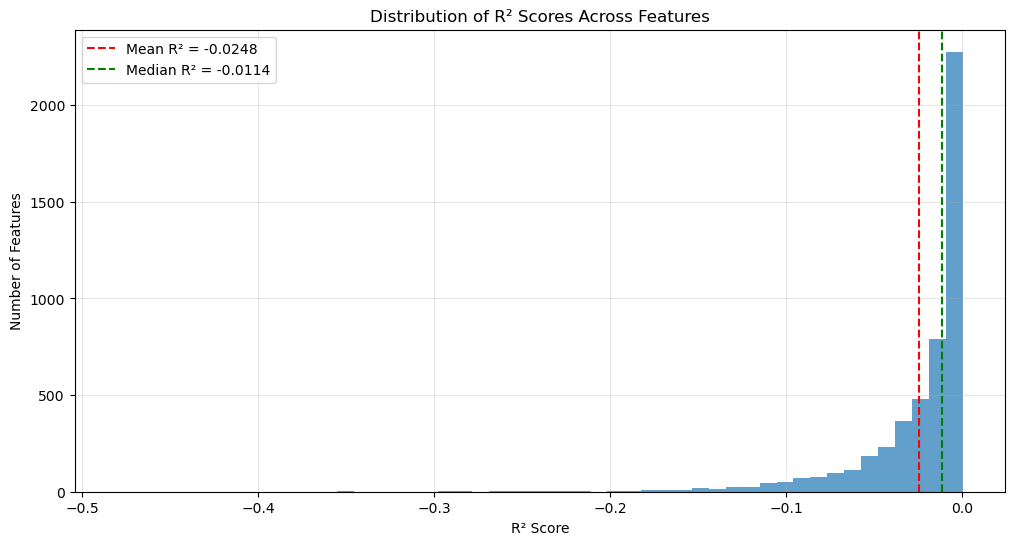

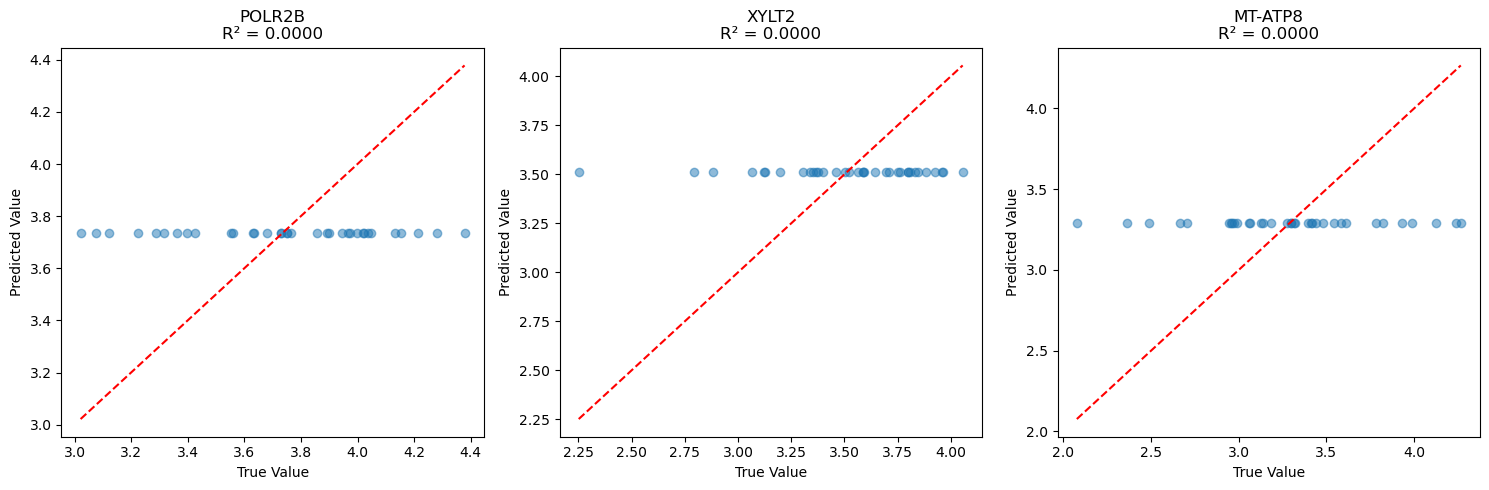

In [ ]:
# Feature Analysis
print("\nAnalysing feature-level performance...")
feature_performance = analyse_feature_level_performance(best_omics_set, best_params, datasets, device)

# Best Predicting Protein Features <a id="results-feature-analysis"></a>

The results that the best predicting proteomic features actually have very low R^2 values, which indicates weak prediction performance and not a lot of variability is explained. The correlation values between the predicted and actual values >0.5 with significant p-values, so the model seems to capture some meaningful relationship between input omics data and protein expression, but not strongly. 


The disconnect between the correlation values and the very low R^2 values suggests that while the model is capturing some general trends in protein expression (hence the correlations), it's not accurately predicting the exact values (hence the poor R^2 values). This could be due to scaling issues in the predictions or systematic biases that the model hasn't learned to correct.


The RMSE values are consistently higher than MAE, suggesting some (larger) errors in the predictions. This because RMSE is more sensitive to outliers (quadratic penalty).